In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import calendar
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Data Loading and preprocessing

In [3]:
# Load the data
file_path = 'PoisonedOnly_NEISS_2004-2023.xlsx'
print(f"Loading data from {file_path}...")
df = pd.read_excel(file_path, sheet_name='ALL (DO NOT EDIT)', dtype=str)

Loading data from PoisonedOnly_NEISS_2004-2023.xlsx...


In [4]:
# Data preprocessing

# Convert weights to numeric
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Create a new categorical column for vitamins
vitamin_codes = ['1927', '1931', '1932']
df['Category'] = np.where(df['Product_1'].isin(vitamin_codes), 'Vitamins', 'Other Exposures')

# Convert Treatment_Date to actual datetime objects
df['Treatment_Date'] = pd.to_datetime(df['Treatment_Date'], errors='coerce')
df['Year'] = df['Treatment_Date'].dt.year
df['Month'] = df['Treatment_Date'].dt.month
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Drop rows with invalid dates
df = df.dropna(subset=['Year', 'Month'])

# Ensure 'Age' column is numeric, converting non-numeric values to NaN (Not a Number)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age_Years'] = np.where(df['Age'] >= 200, (df['Age'] - 200) / 12, df['Age'])

# Age Grouping (<1, 1, 2, 3, 4+)
df['Age_Group'] = np.where(df['Age_Years'] < 1, '<1',
                      np.where(df['Age_Years'] < 2, '1',
                      np.where(df['Age_Years'] < 3, '2',
                      np.where(df['Age_Years'] < 4, '3', '4+'))))

# Mapping standard NEISS codes for readability in plots
sex_map = {'1': 'Male', '2': 'Female', '0': 'Unknown'}
race_map = {'1': 'White', '2': 'Black', '3': 'Other', '0': 'Unknown', np.nan: 'Unknown'}
disp_map = {'1': 'Treated/Released', '2': 'Transferred', '4': 'Admitted', '5': 'Observation', '6': 'Left AMA', '8': 'Fatality', '9': 'Unknown'}
loc_map = {'1': 'Home', '2': 'Farm', '4': 'Street/Highway', '5': 'Public Property', '8': 'School', '9': 'Sports/Recreation', '0': 'Unknown'}
fire_map = {'0': 'No Fire', '1': 'Fire Involved', '2': 'Fire Dept Attended', '3': 'Fire+Dept'}

df['Sex_Label'] = df['Sex'].map(sex_map).fillna('Unknown')
df['Race_Label'] = df['Race'].map(race_map).fillna('Unknown')
df['Disposition_Label'] = df['Disposition'].map(disp_map).fillna('Unknown')
df['Location_Label'] = df['Location'].map(loc_map).fillna('Unknown')
df['Fire_Label'] = df['Fire_Involvement'].map(fire_map).fillna('Unknown')


# YEARLY DATA
# Group by Year and Category, then unstack to create two columns ('Vitamins' and 'Other Exposures')
yearly_data = df.groupby(['Year', 'Category'])['Weight'].sum().unstack(fill_value=0)

# QUARTERLY DATA
# Create a continuous Year-Quarter column (e.g., Q1 2004, Q2 2004)
# .dt.to_period('Q') converts dates to the correct fiscal quarter
# .dt.to_timestamp() converts it back to the first day of that quarter (e.g., Jan 1st, Apr 1st) for plotting
df['YearQuarter'] = df['Treatment_Date'].dt.to_period('Q').dt.to_timestamp()
quarterly_data = df.groupby(['YearQuarter', 'Category'])['Weight'].sum().unstack(fill_value=0)


# INDEXED DATA (Base Year = 100)
# Identify the earliest year to use as the baseline (Index = 100)
base_year = yearly_data.index.min()
# Divide all years by the base year's value and multiply by 100
indexed_data = yearly_data.div(yearly_data.loc[base_year]) * 100


# NORMALIZED SEASONALITY CALCULATION ---

# 1) Sum total ED visits for each specific Month of each Year
monthly_yearly_data = df.groupby(['Year', 'Month', 'Category'])['Weight'].sum().reset_index()

# 2) Sum total ED visits for the entire Year
yearly_totals = monthly_yearly_data.groupby(['Year', 'Category'])['Weight'].sum().reset_index()
yearly_totals = yearly_totals.rename(columns={'Weight': 'Year_Total'})

# 3) Merge and calculate the percentage share that each month contributes to its year
merged_data = pd.merge(monthly_yearly_data, yearly_totals, on=['Year', 'Category'])
merged_data['Month_Share_Pct'] = (merged_data['Weight'] / merged_data['Year_Total']) * 100

# 4) Average these monthly percentages across all 20 years
final_seasonality = merged_data.groupby(['Month', 'Category'])['Month_Share_Pct'].mean().unstack()


# Temporal Analysis

#### Absolute Yearly Trend

To evaluate whether the incidence of vitamin-related ED visits has significantly changed over the 2004-2023 period, an OLS Linear Regression model is applied. The model attempts to fit the best straight line through the annual estimates.

* **Null Hypothesis ($H_0$)**: The slope of the trend line is equal to zero. This implies there is no underlying linear trend over time; the number of annual ED visits is stationary, and any observed variations are purely due to random statistical noise.
* **Alternative Hypothesis ($H_1$)**: The slope of the trend line is not equal to zero. This implies there is a statistically significant linear trend (either increasing or decreasing) in the number of ED visits over the years.

We use a standard significance level of $\alpha = 0.01$ and conclude that the trend is statistically significant.

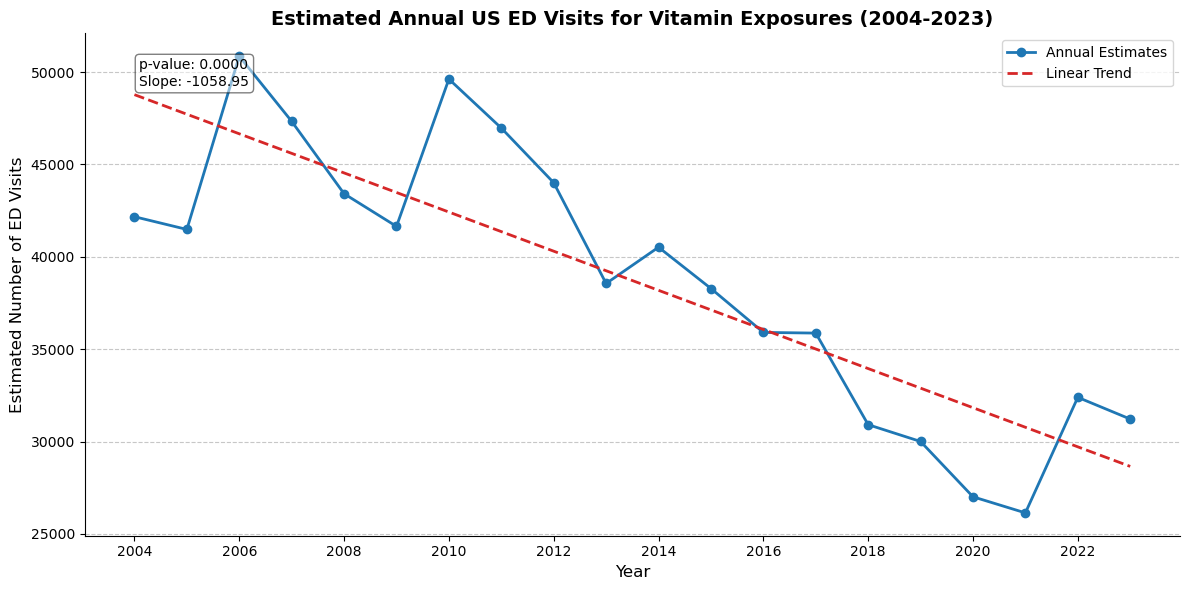

In [5]:
# Prepare the data for regression: X (Year) and y (Estimated Visits)
X = yearly_data.index.values.reshape(-1, 1)
y = yearly_data['Vitamins'].values

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(y, X_with_const).fit()

# Extract the p-value and the slope (coefficient) for the 'Year' variable
# model.pvalues[1] refers to the p-value of the Year coefficient
p_value = model.pvalues[1]
slope = model.params[1]
intercept = model.params[0]

# Generate predicted values for the trend line based on the regression model
trend_line = intercept + slope * yearly_data.index


plt.figure(figsize=(12, 6))

# Plot the actual historical data points and connecting line
plt.plot(yearly_data.index, yearly_data['Vitamins'], 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', 
         markersize=6, label='Annual Estimates')

# Plot the regression trend line to visualize the overall direction
plt.plot(yearly_data.index, trend_line, 
         linestyle='--', color='#d62728', linewidth=2, label='Linear Trend')

# Chart Title and Axis Labels
plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)

# Set X-axis ticks every 2 years for better readability
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))

# Add a text box to display the statistical significance (p-value)
stats_text = f'p-value: {p_value:.4f}\nSlope: {slope:.2f}'
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Aesthetic cleanup: grid, spines, and layout
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend() # Add legend to distinguish data from trend line
plt.tight_layout()

plt.show()

#### Comparative Yearly Trend

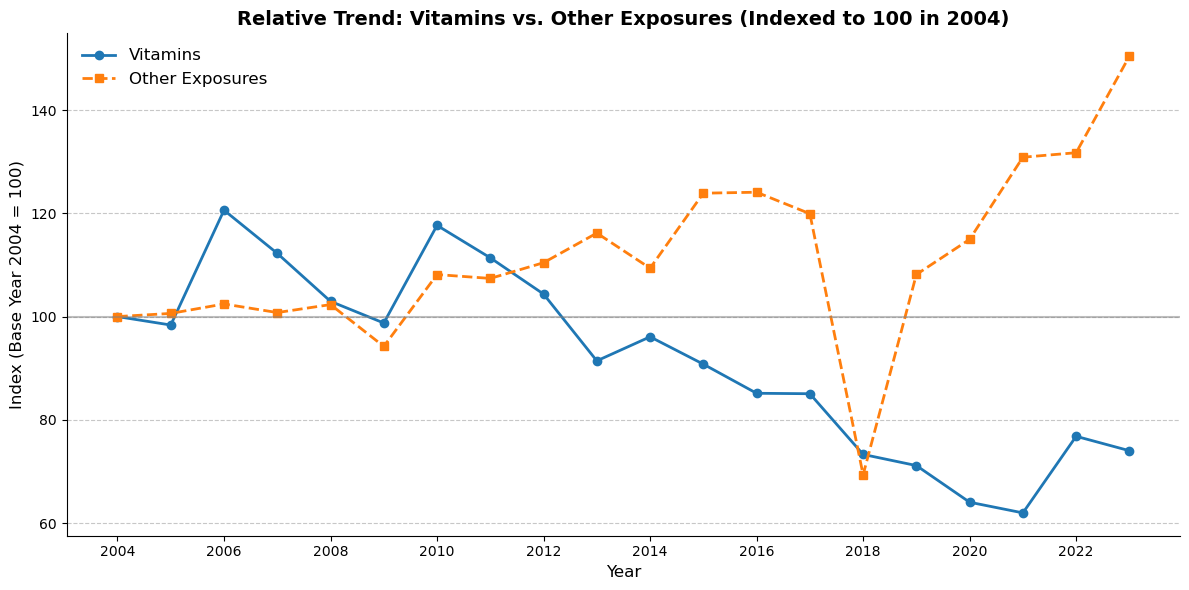

In [6]:
plt.figure(figsize=(12, 6))

# Plot both indexed trends on the same scale
plt.plot(indexed_data.index, indexed_data['Vitamins'], 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=6, label='Vitamins')
plt.plot(indexed_data.index, indexed_data['Other Exposures'], 
         marker='s', linestyle='--', linewidth=2, color='#ff7f0e', markersize=6, label='Other Exposures')

plt.title('Relative Trend: Vitamins vs. Other Exposures (Indexed to 100 in 2004)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Index (Base Year 2004 = 100)', fontsize=12)
plt.xticks(np.arange(min(indexed_data.index), max(indexed_data.index)+1, 2))

# Add a horizontal line at 100 to visually separate growth from decline
plt.axhline(y=100, color='gray', linestyle='-', alpha=0.5)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=False, fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Quarterly Trend

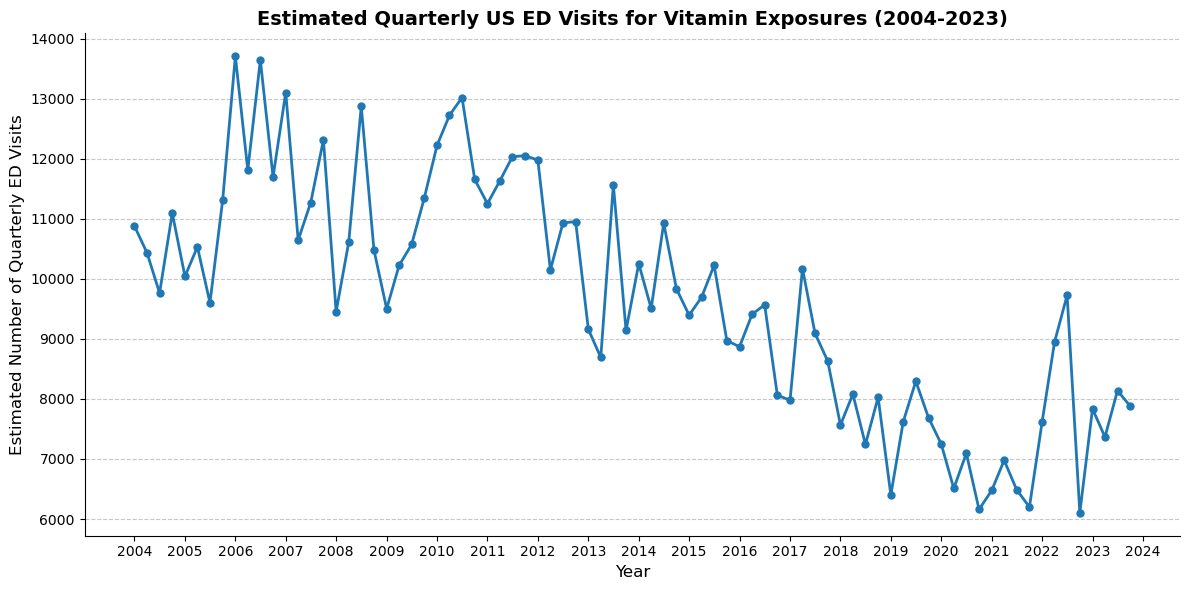

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(quarterly_data.index, quarterly_data['Vitamins'], 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=5)

plt.title('Estimated Quarterly US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of Quarterly ED Visits', fontsize=12)

# Format the X-axis to show a tick for every single year cleanly
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1)) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

#### Seasonality Analysis

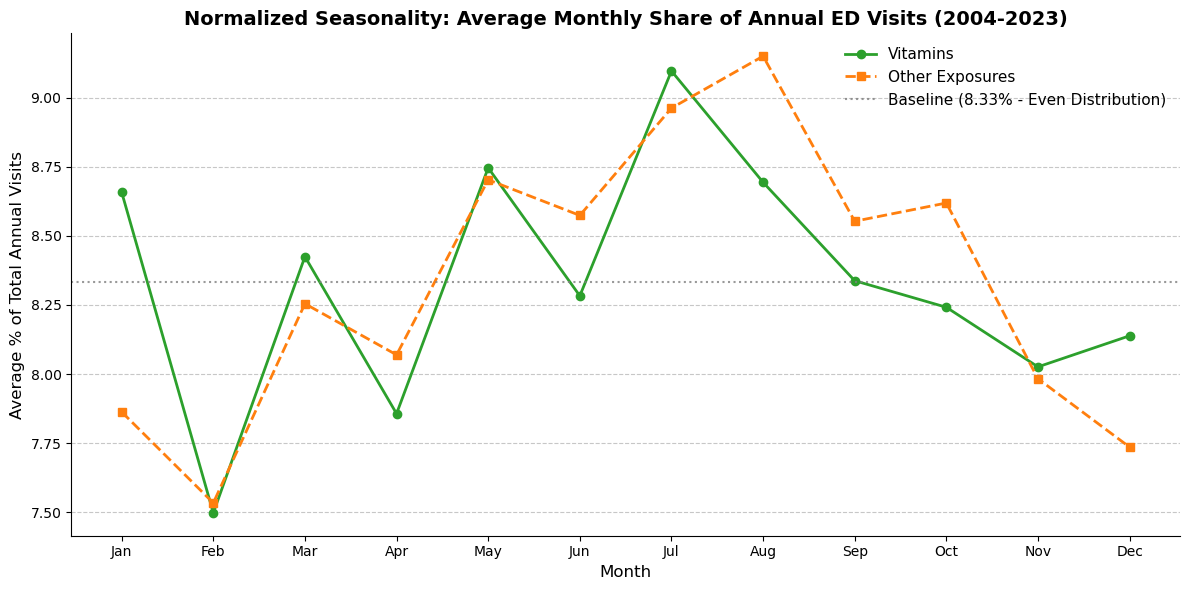

In [8]:
plt.figure(figsize=(12, 6))

# Plot Vitamins
plt.plot(final_seasonality.index, final_seasonality['Vitamins'], 
         marker='o', color='#2ca02c', linewidth=2, label='Vitamins')

# Plot Other Exposures
plt.plot(final_seasonality.index, final_seasonality['Other Exposures'], 
         marker='s', linestyle='--', color='#ff7f0e', linewidth=2, label='Other Exposures')

# Formatting
plt.title('Normalized Seasonality: Average Monthly Share of Annual ED Visits (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average % of Total Annual Visits', fontsize=12)

# Set X-axis to display month names properly using the 'calendar' library
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:13])

# Add a baseline horizontal line (100% / 12 months = 8.33%)
plt.axhline(y=100/12, color='gray', linestyle=':', alpha=0.8, 
            label='Baseline (8.33% - Even Distribution)')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=False, fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Stratified Analysis


### Stratified Trend Analysis: Multivariate Linear Regression with Interaction Terms

To go beyond the global trend and understand the underlying dynamics of vitamin-related exposures, we utilized **Multivariate Ordinary Least Squares (OLS) Linear Regression models incorporating interaction terms**. 

#### Methodology
For each demographic and clinical category (Age, Sex, Race, Disposition), we modeled the estimated annual ED visits as a function of time (`Year`), the categorical variable, and the interaction between the two (`Year * Category`). 
* **Main Effect:** Accounts for the absolute baseline differences in volume between subgroups.
* **Interaction Term:** Measures whether the *slope* (the rate of growth or decline over time) for a specific subgroup is statistically different from the baseline subgroup. A significant interaction $p$-value ($p < 0.05$) indicates that the subgroup's temporal trend is diverging significantly from the baseline, allowing us to identify exactly which populations are driving the overall changes.

#### Summary of Key Findings
In a multivariate linear regression model analyzing temporal trends (2004-2023), significant interactions were observed across multiple demographic and clinical categories, highlighting a clear shift in the epidemiology of vitamin exposures:

* **Age Dynamics:** The most dramatic divergence in age trends was seen in children aged 4+. While exposures in 1-year-olds (the baseline) exhibited a slight decline over the study period, ED visits for the 4+ age group increased at a significantly steeper rate (interaction coefficient: +2851 visits/year, $p < 0.001$). 
* **Sex:** Sex showed no significant impact on the temporal trend, indicating that the shifting exposure patterns affect males and females proportionately ($p = 0.332$). 
* **Clinical Acuity (Disposition):** Crucially, analysis of patient disposition revealed that the annual growth rate of hospital admissions ('Admitted') outpaced that of less severe cases ('Treated/Released'). The negative interaction term for discharged patients relative to admitted patients indicates a statistically significant shift toward higher-acuity presentations over the 20-year study period ($p = 0.004$).

*The following code block iterates through the specified categories, fits the interaction models, and outputs the OLS summary tables containing the respective coefficients, standard errors, and $p$-values.*

   STRATIFIED TREND ANALYSIS & LINEAR REGRESSION (OLS)    

--- Analyzing Category: AGE_GROUP ---


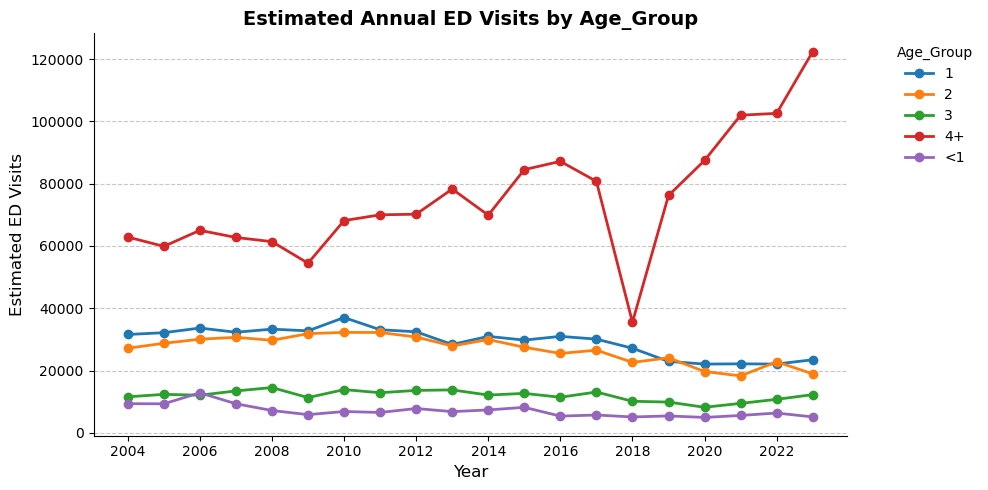

  > 1: Trend = -646.0 visits/year | p-value = 0.0000 (SIGNIFICANT)
  > 2: Trend = -603.8 visits/year | p-value = 0.0000 (SIGNIFICANT)
  > 3: Trend = -150.8 visits/year | p-value = 0.0141 (SIGNIFICANT)
  > 4+: Trend = +2205.6 visits/year | p-value = 0.0011 (SIGNIFICANT)
  > <1: Trend = -251.8 visits/year | p-value = 0.0001 (SIGNIFICANT)


--- Analyzing Category: SEX ---


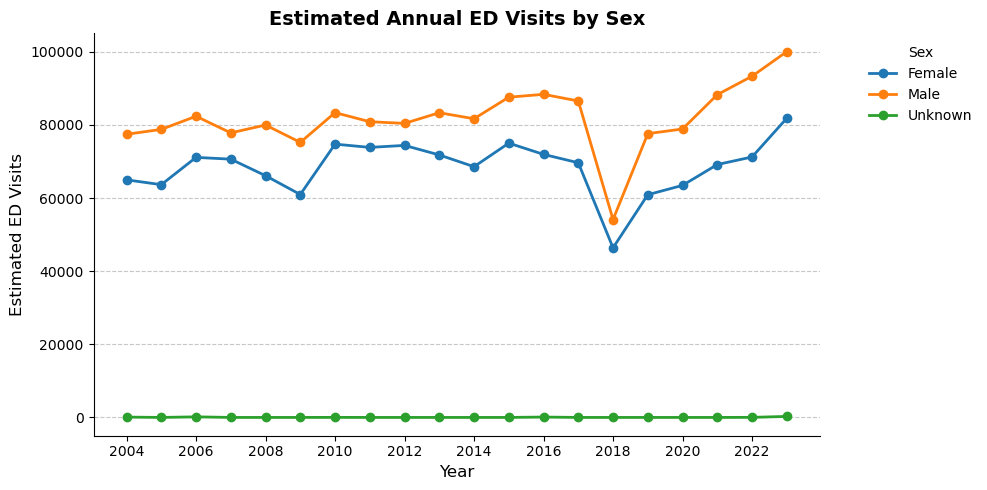

  > Female: Trend = +68.7 visits/year | p-value = 0.8178 (Not Significant)
  > Male: Trend = +483.2 visits/year | p-value = 0.1661 (Not Significant)
  > Unknown: Trend = +1.4 visits/year | p-value = 0.6258 (Not Significant)


--- Analyzing Category: RACE ---


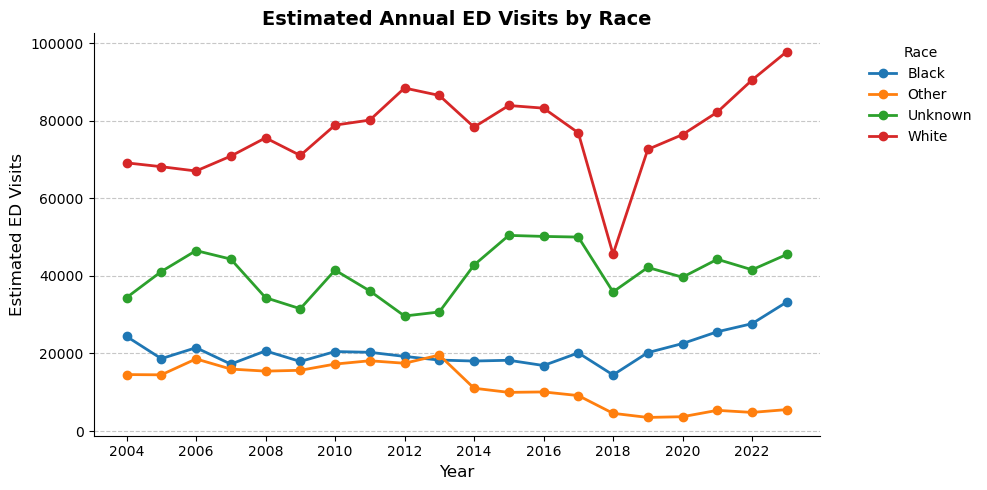

  > Black: Trend = +295.8 visits/year | p-value = 0.0728 (Not Significant)
  > Other: Trend = -792.3 visits/year | p-value = 0.0000 (SIGNIFICANT)
  > Unknown: Trend = +341.4 visits/year | p-value = 0.1797 (Not Significant)
  > White: Trend = +708.4 visits/year | p-value = 0.0964 (Not Significant)


--- Analyzing Category: DISPOSITION ---


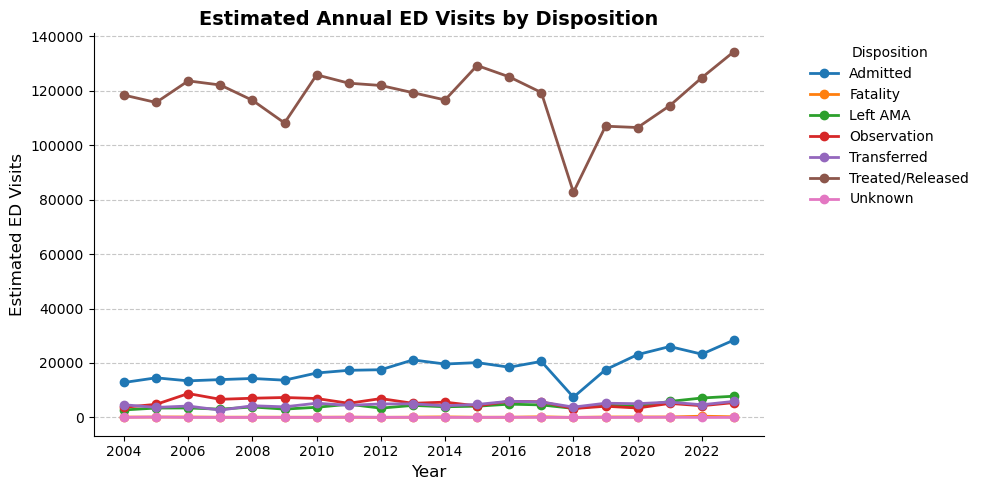

  > Admitted: Trend = +581.4 visits/year | p-value = 0.0008 (SIGNIFICANT)
  > Fatality: Trend = +7.1 visits/year | p-value = 0.0489 (SIGNIFICANT)
  > Left AMA: Trend = +169.9 visits/year | p-value = 0.0001 (SIGNIFICANT)
  > Observation: Trend = -115.3 visits/year | p-value = 0.0370 (SIGNIFICANT)
  > Transferred: Trend = +83.7 visits/year | p-value = 0.0050 (SIGNIFICANT)
  > Treated/Released: Trend = -172.6 visits/year | p-value = 0.6945 (Not Significant)
  > Unknown: Trend = -0.9 visits/year | p-value = 0.5344 (Not Significant)


--- Analyzing Category: LOCATION ---


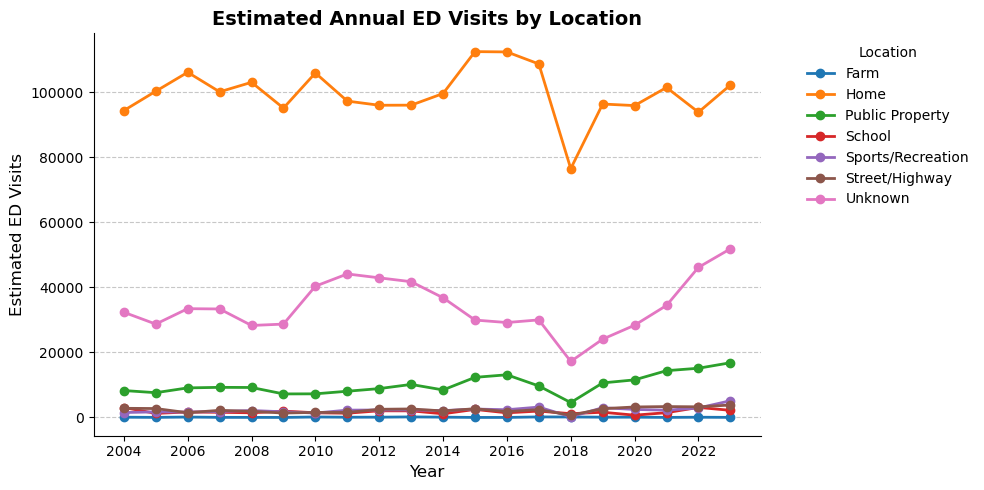

  > Farm: Trend = +0.2 visits/year | p-value = 0.9172 (Not Significant)
  > Home: Trend = -134.4 visits/year | p-value = 0.6733 (Not Significant)
  > Public Property: Trend = +332.5 visits/year | p-value = 0.0018 (SIGNIFICANT)
  > School: Trend = -0.3 visits/year | p-value = 0.9906 (Not Significant)
  > Sports/Recreation: Trend = +87.4 visits/year | p-value = 0.0129 (SIGNIFICANT)
  > Street/Highway: Trend = +60.2 visits/year | p-value = 0.0480 (SIGNIFICANT)
  > Unknown: Trend = +207.7 visits/year | p-value = 0.5349 (Not Significant)


--- Analyzing Category: FIRE INVOLVEMENT ---


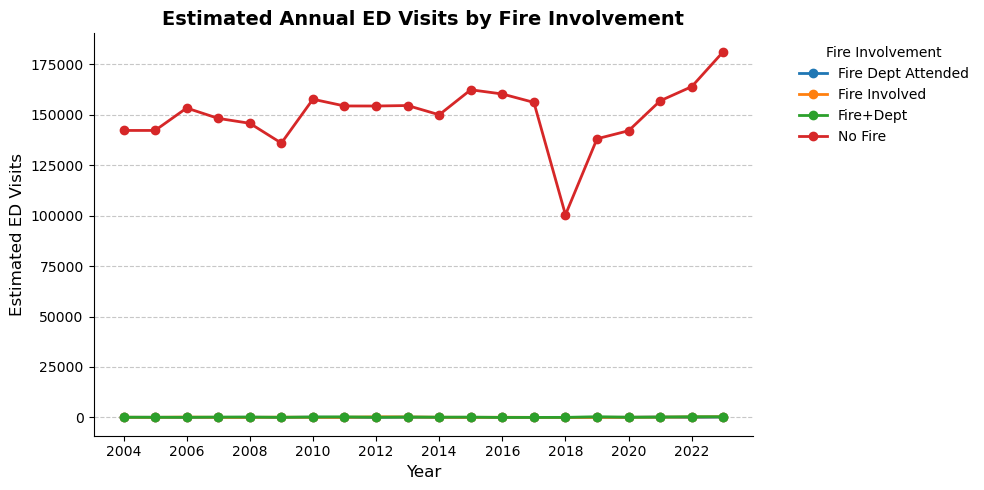

  > Fire Dept Attended: Trend = +2.1 visits/year | p-value = 0.3805 (Not Significant)
  > Fire Involved: Trend = +3.8 visits/year | p-value = 0.3450 (Not Significant)
  > Fire+Dept: Trend = +6.2 visits/year | p-value = 0.1536 (Not Significant)
  > No Fire: Trend = +541.1 visits/year | p-value = 0.3867 (Not Significant)




In [ ]:
categories_to_analyze = {
    'Age_Group': 'Age_Group',
    'Sex': 'Sex_Label',
    'Race': 'Race_Label',
    'Disposition': 'Disposition_Label',
    'Location': 'Location_Label',
    'Fire Involvement': 'Fire_Label'
}

for cat_name, col_name in categories_to_analyze.items():
    print(f"--- Analyzing Category: {cat_name.upper()} ---")
    
    # Raggruppa per Anno e Sottocategoria
    yearly_cat_data = df.groupby(['Year', col_name])['Weight'].sum().unstack(fill_value=0)
    
    # 1. PLOTTING
    plt.figure(figsize=(10, 5))
    for column in yearly_cat_data.columns:
        # Nascondiamo le categorie con 0 dati per pulire il grafico
        if yearly_cat_data[column].sum() > 0:
            plt.plot(yearly_cat_data.index, yearly_cat_data[column], marker='o', linewidth=2, label=str(column))
            
    plt.title(f'Estimated Annual ED Visits by {cat_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Estimated ED Visits', fontsize=12)
    plt.xticks(np.arange(min(yearly_cat_data.index), max(yearly_cat_data.index)+1, 2))
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.legend(title=cat_name, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # 2. REGRESSION ANALYSIS FOR EACH SUB-CATEGORY
    for column in yearly_cat_data.columns:
        if yearly_cat_data[column].sum() == 0:
            continue # Salta le categorie vuote
            
        # Preparazione dati OLS
        X = yearly_cat_data.index.values
        y = yearly_cat_data[column].values
        X_sm = sm.add_constant(X) # Aggiunge l'intercetta
        
        # Fit del modello
        model = sm.OLS(y, X_sm).fit()
        
        trend_coef = model.params[1] # Indice 1 corrisponde alla pendenza (Anno)
        p_value = model.pvalues[1]
        
        # Interpretazione dei risultati
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
        print(f"  > {column}: Trend = {trend_coef:+.1f} visits/year | p-value = {p_value:.4f} ({significance})")
        
    print("\n")

In [ ]:
# Dictionary of categories (Name to print : Column name in the df dataframe)
categories_to_analyze = {
    'Age': 'Age_Group',
    'Sex': 'Sex_Label',
    'Race': 'Race_Label',
    'Disposition': 'Disposition_Label'
}

for cat_name, col_name in categories_to_analyze.items():
    print(f"\n---> MODEL FOR: {cat_name.upper()} <---")
    
    # 1. Prepare the data: group by Year and by the specific Category
    # We obtain a "long" dataframe with columns: Year, [Category], Weight (which we'll rename to Visits)
    df_model = df.groupby(['Year', col_name])['Weight'].sum().reset_index()
    df_model = df_model.rename(columns={'Weight': 'Visits'})
    
    # Remove any categories with very few data points (e.g., Unknown) if they create noise
    # df_model = df_model[df_model[col_name] != 'Unknown']
    
    # 2. Define the formula
    # "Visits ~ Year * C(ColumnName)"
    # C() tells statsmodels to treat the variable as Categorical (creates dummies automatically)
    # The asterisk (*) creates the Main Effects AND the interaction terms automatically
    formula = f"Visits ~ Year * C({col_name})"
    
    # 3. Fit the model
    model = smf.ols(formula=formula, data=df_model).fit()
    
    # 4. Print the full results (Great to copy into the paper)
    print(model.summary().tables[1]) # Print only the coefficients table for a cleaner output
    
    # Automatic explanation for the interaction category
    print("\n  [INTERPRETATION]:")
    print(f"  The baseline category used by the model is indicated in the intercept.")
    print(f"  Look at the 'Year:C({col_name})[T.name]' rows: if the p-value (P>|t|) is < 0.05,")
    print(f"  it means the temporal trend for that category is significantly different from the baseline.")
    print("-" * 60)

 MULTIVARIATE REGRESSION WITH INTERACTION (YEAR * CATEGORY)


---> MODEL FOR: AGE <---
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 1.33e+06   5.32e+05      2.502      0.014    2.74e+05    2.39e+06
C(Age_Group)[T.2]       -8.754e+04   7.52e+05     -0.116      0.908   -1.58e+06    1.41e+06
C(Age_Group)[T.3]       -1.014e+06   7.52e+05     -1.349      0.181   -2.51e+06    4.79e+05
C(Age_Group)[T.4+]      -5.696e+06   7.52e+05     -7.577      0.000   -7.19e+06    -4.2e+06
C(Age_Group)[T.<1]      -8.161e+05   7.52e+05     -1.086      0.281   -2.31e+06    6.77e+05
Year                     -645.9780    264.006     -2.447      0.016   -1170.473    -121.483
Year:C(Age_Group)[T.2]     42.2082    373.361      0.113      0.910    -699.539     783.956
Year:C(Age_Group)[T.3]    495.1689    373.361      1.326      0.188    -246.579    12